<a href="https://colab.research.google.com/github/fdac25/MP2/blob/main/Vis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt



In [3]:
df = pd.read_csv("dlong37_project_summary.csv", sep=";")
df.columns = ['project','commit','author','time','message']
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.strftime('%Y-%m')
df.head()

,project,commit,author,time,message,Month
0,delftdata_valentine,00c5bbd0d4fdddc2a6f2ffec96b4a6472b4c7bef,AndraIonescu <andradenis.ionescu@gmail.com>,1571149530,Added the final correlation clustering framewo...,2019-10
1,delftdata_valentine,01807489e8d20b4b291770b72133f67b2ac8bf87,AndraIonescu <andradenis.ionescu@gmail.com>,1571142631,bug fixes\n,2019-10
2,delftdata_valentine,0191c003dbfe7e8bb45108d4dc55a08213a529b8,kPsarakis <kpsarakis94@gmail.com>,1695917775,update dependencies for python 3.12\n,2023-09
3,delftdata_valentine,01bd0ef43be58ea503b0156861375a65caeb52d7,AndraIonescu <andradenis.ionescu@gmail.com>,1566046826,updated gitignore\n,2019-08
4,delftdata_valentine,01c2d92bfe89bc4d735eda4d5ed9970ed7d8c590,Asterios Katsifodimos <asteriosk@gmail.com>,1582304610,entrypoint\n,2020-02


In [4]:
projects = df['project'].unique()
monthly_series = {}

for prj in projects:
    monthly_counts = df[df['project']==prj].groupby('Month').size().reset_index(name='Commits')
    monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
    full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
    monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
    monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')
    monthly_counts['Commits'] = monthly_counts['Commits'].astype(int)
    monthly_series[prj] = monthly_counts

    monthly_counts[['Month','Commits']].rename(columns={'Commits':'#Commits'}).to_csv(
        "dlong37_commits_timeseries_"+prj+".csv", index=False, sep=";")


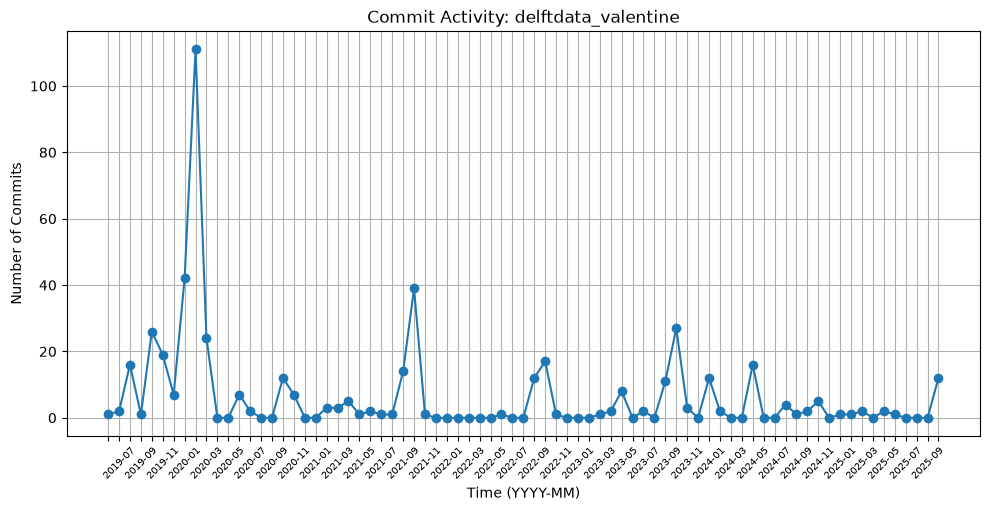

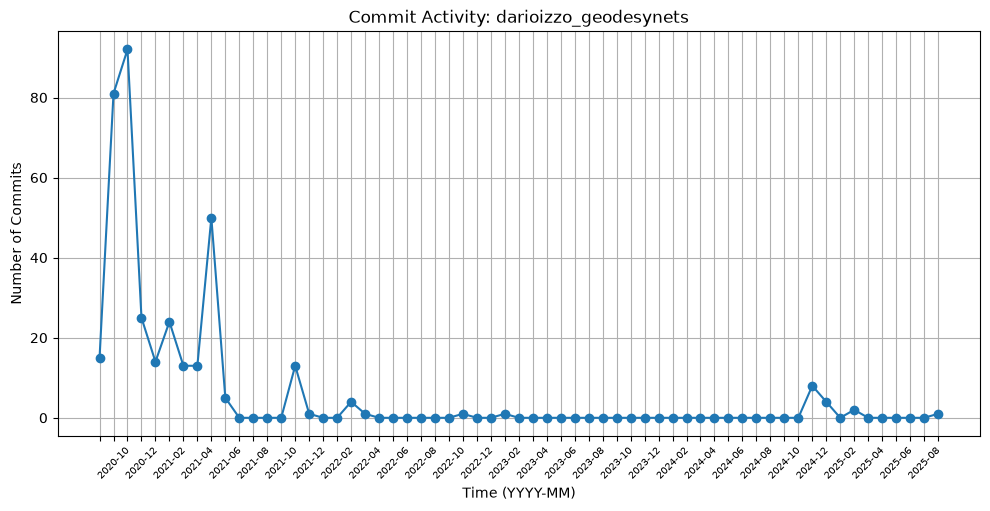

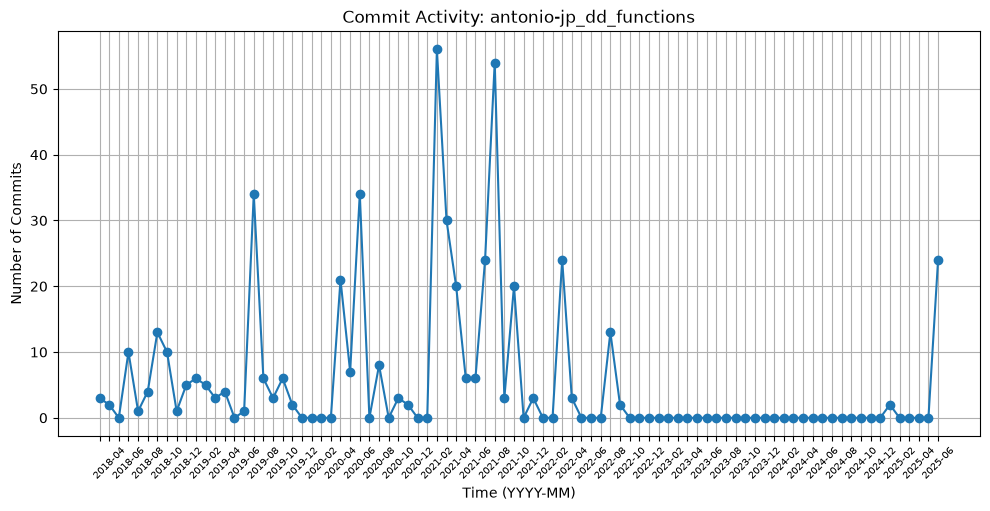

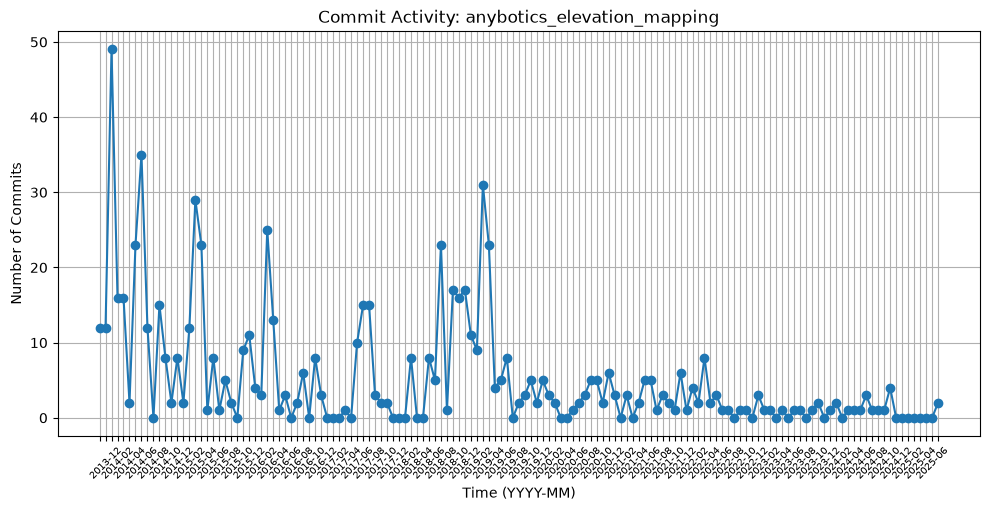

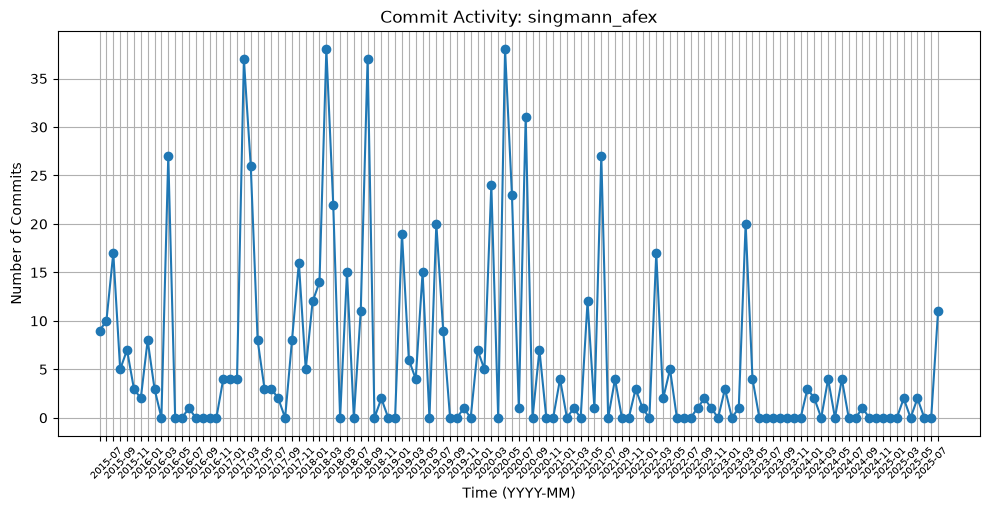

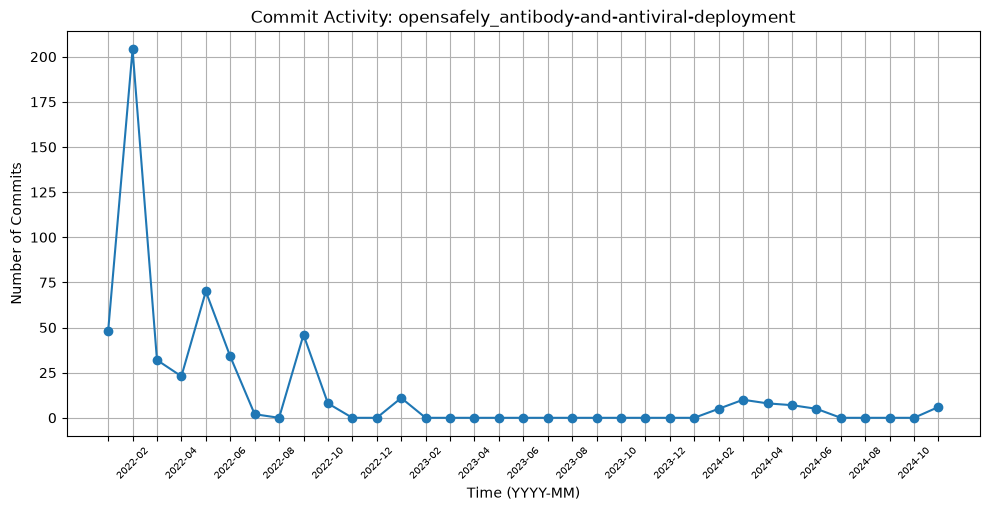

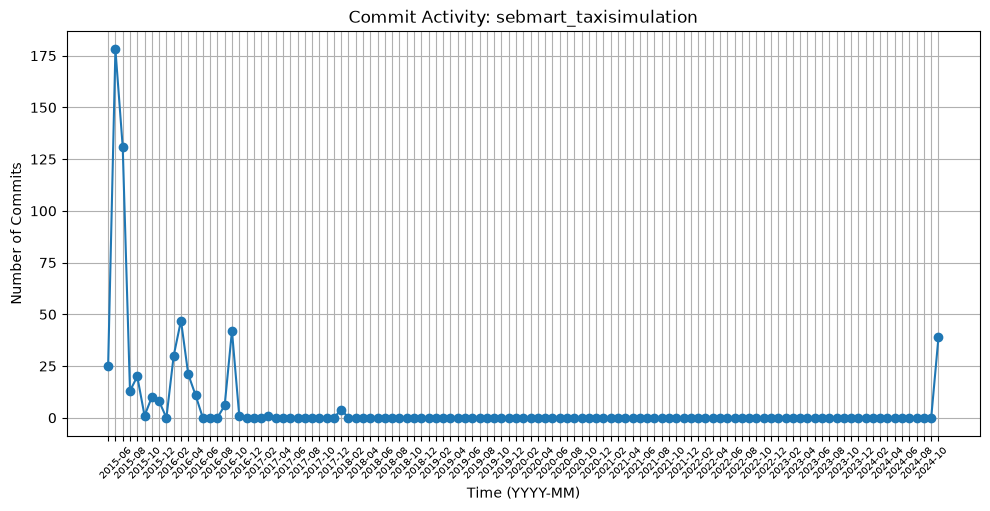

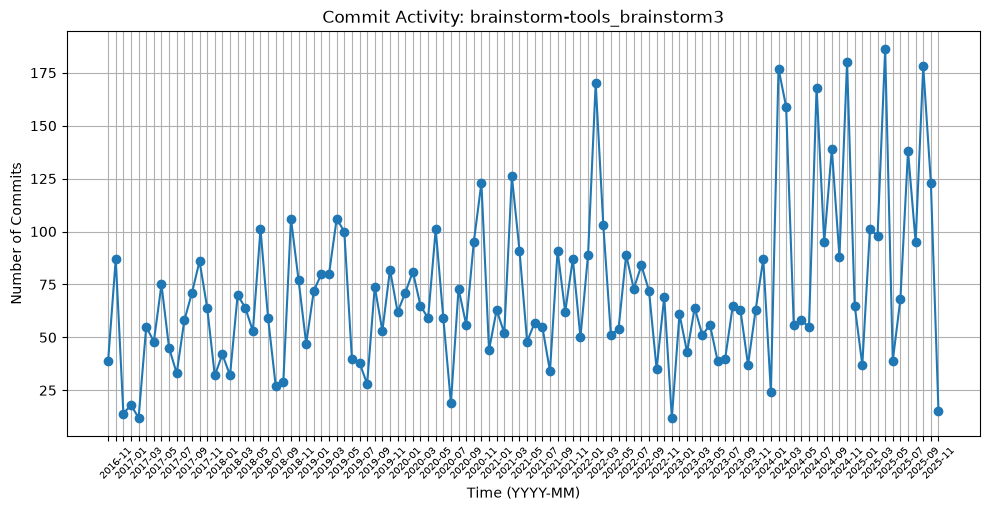

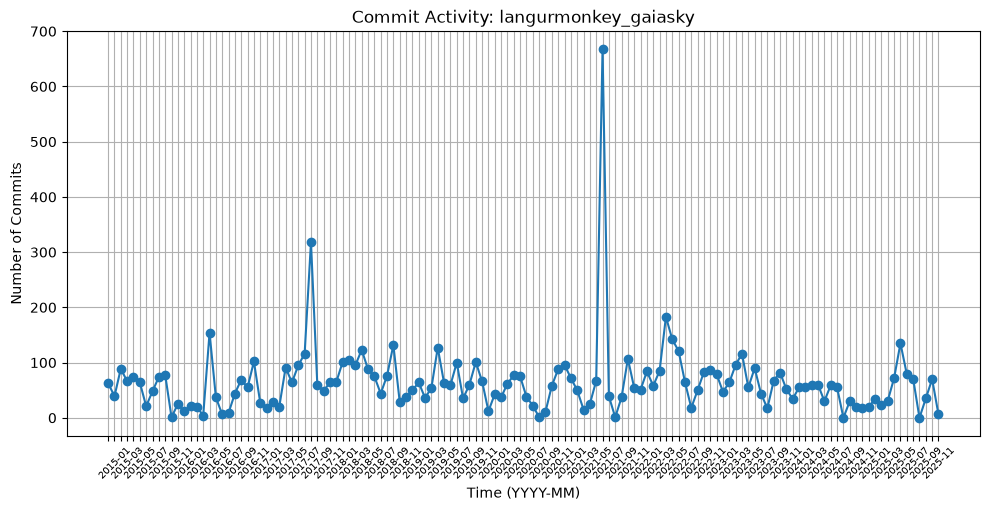

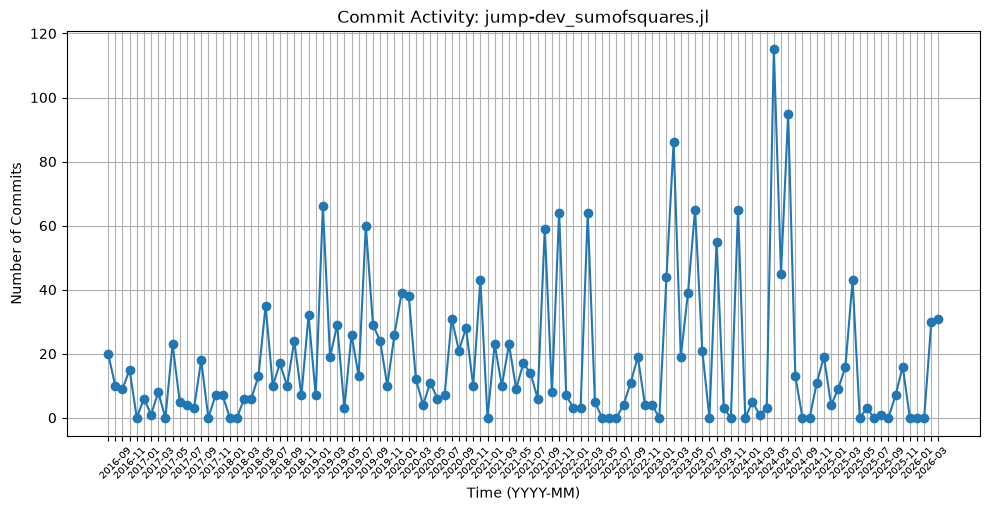

In [5]:
# Plot
import matplotlib.ticker as ticker

for prj, monthly_counts in monthly_series.items():
    plt.figure(figsize=(10,5))
    plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
    plt.xlabel("Time (YYYY-MM)")
    plt.ylabel("Number of Commits")
    plt.title("Commit Activity: "+prj)
    plt.grid(True)
    plt.tight_layout()
    ax =  plt.gca()
    for label in ax.xaxis.get_ticklabels()[::2]:
        label.set_visible(False)
    plt.xticks(rotation=45, fontsize=7)
    plt.savefig("dlong37_timeseries_"+prj+".png", dpi=600)
    plt.show()
    plt.close()


# Identify the Longest Inactivity Gap

2022-02 to 2023-04

Add all that info to netid_project_stats.csv

In [ ]:
# Correctly ordered columns for reindexing DataFrame later.
ordered_columns = ["project", "#commits", "#authors", "From", "To",
                    "#stars", "#forks", "LastGHCommitDate", "LongestGapStart",
                    "LongestGapEnd", "LongestGapLength", "NumCommitsAfterLastGap",
                    "NumberOfGapsInTimeline", "ActivityPattern"]

# Create dataframe containing #commits, #authors, min time, and max time for all projects.
summary = df.groupby('project').agg(
     total_commits=('commit', 'count'),
     num_authors=('author', 'nunique'),
     from_time=('time', 'min'),
     to_time=('time', 'max')
).reset_index()

rows = []

# Dictionaries for #stars, #forks, LastGHCommitDate, and ActivityPattern for all projects.
num_stars = {
    "delftdata_valentine": "126",
    "darioizzo_geodesynets": "20",
    "antonio-jp_dd_functions": "4",
    "anybotics_elevation_mapping": "1.9K",
    "singmann_afex": "131",
    "opensafely_antibody-and-antiviral-deployment": "1",
    "sebmart_taxisimulation": "17",
    "brainstorm-tools_brainstorm3": "487",
    "langurmonkey_gaiasky": "13",
    "jump-dev_sumofsquares.jl": "131"
}
num_forks = {
    "delftdata_valentine": "26",
    "darioizzo_geodesynets": "5",
    "antonio-jp_dd_functions": "3",
    "anybotics_elevation_mapping": "507",
    "singmann_afex": "30",
    "opensafely_antibody-and-antiviral-deployment": "4",
    "sebmart_taxisimulation": "11",
    "brainstorm-tools_brainstorm3": "190",
    "langurmonkey_gaiasky": "1",
    "jump-dev_sumofsquares.jl": "26"
}
last_commit = {
    "delftdata_valentine": "2026/07/26",
    "darioizzo_geodesynets": "2025/09/16",
    "antonio-jp_dd_functions": "2022/03/03",
    "anybotics_elevation_mapping": "2024/11/04",
    "singmann_afex": "2025/12/14",
    "opensafely_antibody-and-antiviral-deployment": "2024/02/13",
    "sebmart_taxisimulation": "2024/11/14",
    "brainstorm-tools_brainstorm3": "2026/09/15",
    "langurmonkey_gaiasky": "2026/09/22",
    "jump-dev_sumofsquares.jl": "2026/09/21"
}
patterns = {
     "delftdata_valentine": "steady",
     "darioizzo_geodesynets": "steady",
     "antonio-jp_dd_functions": "irregular",
     "anybotics_elevation_mapping": "declining",
     "singmann_afex": "cyclical",
     "opensafely_antibody-and-antiviral-deployment": "declining",
     "sebmart_taxisimulation": "declining",
     "brainstorm-tools_brainstorm3": "cyclical",
     "langurmonkey_gaiasky": "steady",
     "jump-dev_sumofsquares.jl": "irregular"
}

# Calculates LongestGapStart, LongestGapEnd, LongestGapLength, NumCommitsAfterLastGap, and
# NumberOfGapsInTimeline for all projects
for prj, monthly_counts in monthly_series.items():
    start_month = 0
    length = 0
    num_gap_months = 0

    best_start = 0
    best_end = 0
    best_length = 0
    num_gaps = 0
    num_commits_post_best_end = 0

    for month, counts in zip(monthly_counts['Month'], monthly_counts['Commits']):
        # Start of a new gap
        if counts == 0:
            if start_month == 0:
                    start_month = month
            
            length += 1
            num_gap_months += 1

            # Count three-month minimum gaps
            if (num_gap_months == 3):
                num_gaps += 1

            # Replace previous longest gap if new gap is longer
            if best_length < length:
                best_length = length
                best_start = start_month
                best_end = month
                num_commits_post_best_end = 0
        else:
            # Reset gap info if activity is present
            length = 0
            start_month = 0
            num_gap_months = 0

            # Add commit counts if longest gap is present
            if best_end != 0:
                 num_commits_post_best_end += counts

    # Place N/A values for repos with no gaps
    if best_length == 0:
         best_start = 'N/A'
         best_end = 'N/A'
         num_commits_post_best_end = 'N/A'

    # Printing information for sanity check
    print('-' * len(prj))
    print(f"{prj}")
    print('-' * len(prj))
    print(f"Longest Gap: {best_start} -> {best_end}")
    print(f"# of Months in Longest Gap: {best_length}")
    print(f"# of Gaps: {num_gaps}")
    print(f"# of Commits After Last Gap: {num_commits_post_best_end}")

    # Append project information to array
    rows.append({'project': prj, '#stars': num_stars[prj], '#forks': num_forks[prj],
                 'LastGHCommitDate': last_commit[prj], 'LongestGapStart': best_start,
                 'LongestGapEnd': best_end, 'LongestGapLength': best_length,
                 'NumCommitsAfterLastGap': num_commits_post_best_end,
                 'NumberOfGapsInTimeline': num_gaps, "ActivityPattern": patterns[prj]})

# Create DataFrame from project info array
stats = pd.DataFrame(rows)

# Merge both DataFrame together and rename columns from first DataFrame
stats = pd.merge(stats, summary, on='project')
stats.rename(columns={
     'total_commits': '#commits',
     'num_authors': '#authors',
     'from_time': 'From',
     'to_time': 'To'
}, inplace=True)

# Reorder columns to match example CSV
stats = stats.reindex(columns=ordered_columns)

# Print head of DataFrame for sanity check
stats.head()

# Create CSV file of DataFrame
stats.to_csv('dlong37_project_stats.csv', index=False,sep=';')


-------------------
delftdata_valentine
-------------------
Longest Gap: 2021-12 -> 2022-05
# of Months in Longest Gap: 6
# of Gaps: 3
# of Commits After Last Gap: 146
---------------------
darioizzo_geodesynets
---------------------
Longest Gap: 2023-03 -> 2024-11
# of Months in Longest Gap: 21
# of Gaps: 4
# of Commits After Last Gap: 15
-----------------------
antonio-jp_dd_functions
-----------------------
Longest Gap: 2022-10 -> 2024-12
# of Months in Longest Gap: 27
# of Gaps: 4
# of Commits After Last Gap: 26
---------------------------
anybotics_elevation_mapping
---------------------------
Longest Gap: 2024-12 -> 2025-06
# of Months in Longest Gap: 7
# of Gaps: 3
# of Commits After Last Gap: 2
-------------
singmann_afex
-------------
Longest Gap: 2023-06 -> 2023-12
# of Months in Longest Gap: 7
# of Gaps: 4
# of Commits After Last Gap: 29
--------------------------------------------
opensafely_antibody-and-antiviral-deployment
--------------------------------------------
Long